# Bigfoot Sighting Data Analysis


## This dataset, sourced from Kaggle.com and the BFRO (Bigfoot Field Researchers Organization), documents Bigfoot sightings, including noise, visual, and track evidence.

* **Collaboration:** This assignment was completed in collaboration with Pavani Ravella.

**This project analyzes data on reported Bigfoot sightings over the years. We will be using the following excel file called "bfro_reports_geocoded.csv" to load and inspect our data.The dataset includes information such as state, county, longitude, and latitude. We will perform exploratory data analysis, data imputation, and apply machine learning algorithms to gain insights from this data.**

**The following table describes the columns in the dataset:**

| Column             | Description                                  | Data Type |
| ------------------ | -------------------------------------------- | --------- |
| `observed`         | Date and time of the sighting                | DateTime  |
| `location_details` | Specific location of the sighting            | String    |
| `county`           | County where the sighting occurred           | String    |
| `state`            | State where the sighting occurred            | String    |
| `season`           | Season of the sighting                         | String    |
| `title`            | Title of the sighting report                   | String    |
| `latitude`         | Latitude of the sighting                       | Float     |
| `longitude`        | Longitude of the sighting                      | Float     |
| `number`           | Report number of the sighting                | Integer   |
| `classification`   | Classification of the sighting                 | String    |
| `geohash`          | Geohash of the sighting                        | String    |
| `temperature_high` | High temperature on the sighting day         | Float     |
| `temperature_low`  | Low temperature on the sighting day          | Float     |
| `dew_point`        | Dew point on the sighting day                | Float     |
| `cloud_cover`      | Cloud cover on the sighting day              | Float     |
| `moon_phase`       | Moon phase on the sighting day               | String    |
| `precip_intensity` | Precipitation intensity on the sighting day  | Float     |
| `precip_probability`| Precipitation probability on the sighting day| Float     |
| `precip_type`      | Precipitation type on the sighting day       | String    |
| `pressure`         | Atmospheric pressure on the sighting day     | Float     |
| `summary`          | Weather conditions summary on sighting day   | String    |
| `visibility`       | Visibility on the sighting day               | Float     |
| `wind_bearing`     | Wind bearing on the sighting day             | Integer   |
| `wind_speed`       | Wind speed on the sighting day               | Float     |

In [1]:
#Let's load the data and inspect the data using the head function for a sample of dataset.
import pandas as pd
df = pd.read_csv("bfro_reports_geocoded.csv")

In [2]:
pd.set_option('display.max_columns', None)
df.head()

,index,observed,location_details,county,state,season,title,latitude,longitude,date,number,classification,geohash,temperature_high,temperature_mid,temperature_low,dew_point,humidity,cloud_cover,moon_phase,precip_intensity,precip_probability,precip_type,pressure,summary,uv_index,visibility,wind_bearing,wind_speed
0,0,I was canoeing on the Sipsey river in Alabama....,NaN,Winston County,Alabama,Summer,NaN,NaN,NaN,NaN,30680.0,Class B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Ed L. was salmon fishing with a companion in P...,East side of Prince William Sound,Valdez-Chitina-Whittier County,Alaska,Fall,NaN,NaN,NaN,NaN,1261.0,Class A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"While attending U.R.I in the Fall of 1974,I wo...","Great swamp area, Narragansett Indians",Washington County,Rhode Island,Fall,Report 6496: Bicycling student has night encou...,41.45,-71.5,1974-09-20,6496.0,Class A,drm5ucxrc0,78.17,73.425,68.68,65.72,0.86,0.86,0.16,0.0,0.0,NaN,1020.61,Foggy until afternoon.,4.0,2.75,198.0,6.92
3,3,"Hello, My name is Doug and though I am very re...",I would rather not have exact location (listin...,York County,Pennsylvania,Summer,NaN,NaN,NaN,NaN,8000.0,Class B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,It was May 1984. Two friends and I were up in ...,"Logging roads north west of Yamhill, OR, about...",Yamhill County,Oregon,Spring,NaN,NaN,NaN,NaN,703.0,Class B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's review the column data types further to understand and make sure the data is in it's appropriate format. We can see that temperature and humidity are correctly identified as floats. We also have categorical columns for state, county, season etc. Based on the review, date column needs to be convered to a date time format which we will be doing in the later part of the assignment.

In [3]:
df.dtypes

index                   int64
observed               object
location_details       object
county                 object
state                  object
season                 object
title                  object
latitude              float64
longitude             float64
date                   object
number                float64
classification         object
geohash                object
temperature_high      float64
temperature_mid       float64
temperature_low       float64
dew_point             float64
humidity              float64
cloud_cover           float64
moon_phase            float64
precip_intensity      float64
precip_probability    float64
precip_type            object
pressure              float64
summary                object
uv_index              float64
visibility            float64
wind_bearing          float64
wind_speed            float64
dtype: object

We'll check for missing values to determine the necessary imputation strategies. Based on the code below, we are noticing that there quite a few missing values in a lot of columns and we will have to identify and implement suitable data imputation techniques on these.

In [4]:
df.isna().sum()

index                    0
observed                38
location_details       760
county                   0
state                    0
season                   0
title                  976
latitude               976
longitude              976
date                   976
number                   0
classification           0
geohash                976
temperature_high      1683
temperature_mid       1835
temperature_low       1832
dew_point             1648
humidity              1648
cloud_cover           1937
moon_phase            1625
precip_intensity      2309
precip_probability    2311
precip_type           3298
pressure              2402
summary               1655
uv_index              1629
visibility            1972
wind_bearing          1634
wind_speed            1632
dtype: int64

**Question 1:**
Let's perform basic data exploration to understand the distrubtion of the class to understand how the sightings have been recorded. Class is currently classified as Class A, B, C (Possible related to noise, track and sight), but the dataset doesn't clearly determine which one is what and hence we can only find the distribution of the three class but we can't map it to actual titles). Although class types (possibly related to noise, track, and sight) are unclear, we can determine the unique classes and visualize their counts to make sure we have enough of the data to explore.

In [5]:
df['classification'].unique()

array(['Class B', 'Class A', 'Class C'], dtype=object)

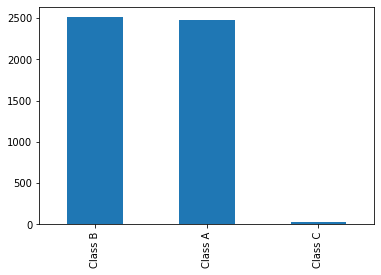

In [6]:
import matplotlib.pyplot as plt
df['classification'].value_counts().plot.bar()
plt.show()

We can see that Class A and Class B are the most occuring classes with very minimal values for Class C. If we end up doing Machine learning on this, we will have to resample data for Class C to add more synthetic data to keep the distribution of class close to even for the three classification types.

**Question 2**

I would like to explore the states where bigfoot sightings are mostly found and also visualize it. We will identify the the top 10 states where most sightings are found and visualize it in a bar graph.

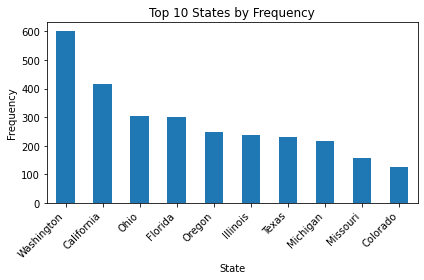

In [7]:
top_10_states = df['state'].value_counts().nlargest(10)

# Create the line graph
top_10_states.plot(kind='bar')
plt.title('Top 10 States by Frequency')
plt.xlabel('State')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Based on the above visualation we can conclude that the dataset has bigfoot sighting from all over United states and it is not concentrated to any specific parts of the country. Washington has the most number of sightings followed by California and Ohio which is a diverse collection of locations with no specific patterns or anything associated with it.

**Question 3:**

I would like to explore if bigfoot sightings are increasing over recent years or if they remain the same throughout the years. We can do this by creating a new column for year which will be extracted from the date feature and see trends over the years. We will also be removing the missing data that corresponds to date as we are trying to see trends over date variable.

In [8]:
df_data = df.copy()
df_data = df_data.dropna(subset=['date'])
df_data['date'] = pd.to_datetime(df_data['date'])
df_data['year'] = df_data['date'].dt.year
df_data.head()

,index,observed,location_details,county,state,season,title,latitude,longitude,date,number,classification,geohash,temperature_high,temperature_mid,temperature_low,dew_point,humidity,cloud_cover,moon_phase,precip_intensity,precip_probability,precip_type,pressure,summary,uv_index,visibility,wind_bearing,wind_speed,year
2,2,"While attending U.R.I in the Fall of 1974,I wo...","Great swamp area, Narragansett Indians",Washington County,Rhode Island,Fall,Report 6496: Bicycling student has night encou...,41.45000,-71.50000,1974-09-20,6496.0,Class A,drm5ucxrc0,78.17,73.425,68.68,65.72,0.86,0.86,0.16,0.0,0.0,NaN,1020.61,Foggy until afternoon.,4.0,2.750,198.0,6.92,1974
5,5,My two children and I were returning from Altu...,The creature crossed from one cattle pasture t...,Washita County,Oklahoma,Fall,Report 9765: Motorist and children have daylig...,35.30110,-99.17020,1973-09-28,9765.0,Class A,9y32z667yc,71.86,61.425,50.99,51.03,0.79,0.11,0.07,NaN,NaN,rain,1017.26,Partly cloudy starting in the afternoon.,7.0,10.000,259.0,8.41,1973
6,6,I was staying the night with a friends of mine...,"Vincent, Ohio (In theWayne National Forest)",Washington County,Ohio,Summer,Report 4983: Sighting and vocalizations at a h...,39.38745,-81.67339,1971-08-01,4983.0,Class A,dpjbj6r280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1971
7,7,Well last year I was night fishing 9/2010 at A...,Both sightings were on the North east corner o...,Westchester County,New York,Fall,Report 31940: Fishermen and Law Enforcement Of...,41.29873,-73.73717,2010-09-01,31940.0,Class A,dr7dfn4nx3,92.24,80.810,69.38,67.34,0.68,0.05,0.76,0.0,0.0,NaN,1016.80,Clear throughout the day.,8.0,6.922,219.0,1.01,2010
8,8,I grew up in Northwestern Nevada along the Cal...,"The Western face of Peavine Mountain, Northwes...",Washoe County,Nevada,Fall,Report 5692: Father and son hear vocalizations...,39.59200,-119.97500,1970-09-01,5692.0,Class B,9r49jzsb5g,NaN,NaN,NaN,32.55,0.45,0.00,0.02,0.0,0.0,NaN,1012.31,Clear throughout the day.,8.0,8.880,285.0,4.01,1970


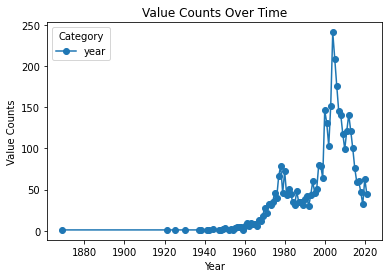

In [9]:
# Calculate value counts per year
value_counts_by_year = df_data['year'].value_counts().sort_index()

# Plotting
value_counts_by_year.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Value Counts')
plt.title('Value Counts Over Time')
plt.legend(title='Category')
plt.show()

Based on the above graph, we can see that from year 1880 to 1960 there have been almost no sighting of these bigfoot but after that we can clearly a spike in the sighting that peaked after 2000's and started to decline closer towards 2020. It intituive makes sense as technology and data collection process have improved, more data is available which is reflected in the data trends. We would enhance the visualation by filtering the graph to show only from years 1960 onwards to observe and understand the spikes better.

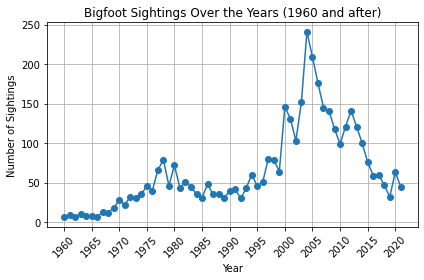

In [10]:
filtered_df = df_data[df_data['year'] >= 1960]
value_counts_by_year = filtered_df['year'].value_counts().sort_index()

value_counts_by_year.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Sightings')
plt.title('Bigfoot Sightings Over the Years (1960 and after)')
plt.grid(True)

# Set x-axis ticks every 5 years
years = value_counts_by_year.index
plt.xticks(ticks=range(min(years), max(years)+1, 5), rotation=45)

plt.tight_layout()
plt.show()

Based on the graph above, we can see that data spiked around year 2003 or 2004 and then went downwards from there. There is no clear phenomenon that we can so far use to explain this declining data trends after 2005.

**Question 4:**

We're curious to see if Bigfoot tends to show up more in certain seasons or when the weather hits specific temperatures. So, we'll look at how sightings vary by season and also group temperatures to see if there's a range where sightings happen more often. We will perform value counts on seasons and also group temperatures based on range to see if there are any specific temperature range that had the most number of sightings.

In [11]:
df['season'].unique()


array(['Summer', 'Fall', 'Spring', 'Winter', 'Unknown'], dtype=object)

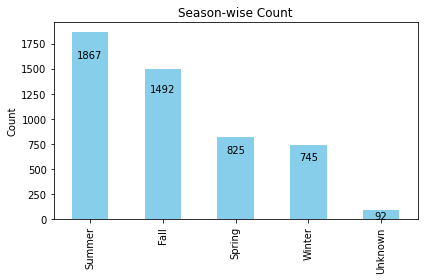

In [12]:
value_counts = df['season'].value_counts()
ax = value_counts.plot.bar(color='skyblue')

for i, count in enumerate(value_counts):
    ax.text(i, count - (count * 0.1), str(count), ha='center', va='top', color='black', fontsize=10)

plt.ylabel('Count')
plt.title('Season-wise Count')
plt.tight_layout()
plt.show()

Based on the data above, we can see that summer has the most sightings of the bigfoot where as winter has the least sighting. We also have 92 in the unknown category. We can try to convert the unknown seasons into a known season by converting the seasons based on the dates listed. We can do mapping functions where we will say anything that falls in december, january, february will be winter, march,april, may will be spring, june,july,august will be summer and september,october and november will be fall.

In [13]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Unknown'

df['season'] = df.apply(
    lambda row: month_to_season(row['date'].month) if row['season'] == 'Unknown' and pd.notnull(row['date']) else row['season'],
    axis=1
)

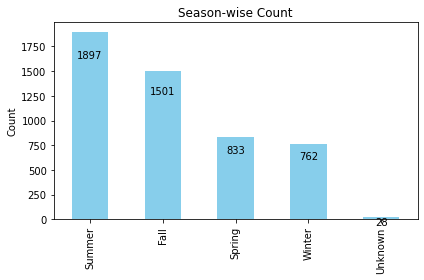

In [14]:
value_counts = df['season'].value_counts()
ax = value_counts.plot.bar(color='skyblue')

for i, count in enumerate(value_counts):
    ax.text(i, count - (count * 0.1), str(count), ha='center', va='top', color='black', fontsize=10)

plt.ylabel('Count')
plt.title('Season-wise Count')
plt.tight_layout()
plt.show()

This process of data cleaning has helped us clean the unknown value in seasons from 92 to 26 thereby giving us more clarity on the dataset. In general, it seems like warmer seasons has more sighting than the colder season.

Next steps would be to compare the number of sightings based on mid temperature per day to see if warmer weather generally gives us more sightings. We will group temperature into various temperate range and map the values of temperatures into a categorical bin variable and then we will get value counts.

In [15]:
df['temperature_mid'].describe()

count    3186.000000
mean       57.843377
std        16.396587
min        -8.455000
25%        46.767500
50%        59.360000
75%        70.380000
max        94.030000
Name: temperature_mid, dtype: float64

Based on the temperature above, we will bin the temperature into 4 categories to say anything below 30 will be freezing, anything between 30-60 will be cold, anything between 60-80 will be pleasant and anything over 80 will be hot.

Hot         2066
Cold        1476
Pleasant    1318
Freezing     161
Name: temp_category, dtype: int64


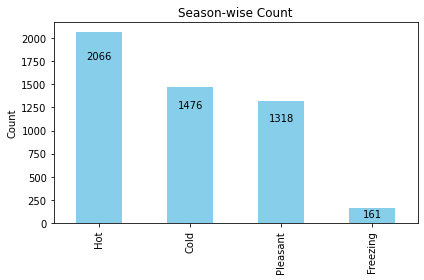

In [16]:
def categorize_temp(temp):
    if temp < 30:
        return 'Freezing'
    elif temp < 60:
        return 'Cold'
    elif temp < 80:
        return 'Pleasant'
    else:
        return 'Hot'

# Apply the function using map()
df['temp_category'] = df['temperature_mid'].map(categorize_temp)

# View the counts
print(df['temp_category'].value_counts())

value_counts = df['temp_category'].value_counts()
ax = value_counts.plot.bar(color='skyblue')

for i, count in enumerate(value_counts):
    ax.text(i, count - (count * 0.1), str(count), ha='center', va='top', color='black', fontsize=10)

plt.ylabel('Count')
plt.title('Season-wise Count')
plt.tight_layout()
plt.show()

This further clarifies our assumption that hot temperatures are leading to more sightings. There is no noticeable differences between cold and pleasant and in freezing conditions, the sightings are very low. Another factor to consider here would be that more people may not go out during winter months and hence there could be low numebr of records. However, we have to investigate this further to test that hypothesis.

**Question 5:**
    
Let's explore the data a little bit further to see if seasonlity for different states plays a role in these bigfoot sightings. We will do groupby function between state and season to understand if there are patterns that can explain if different state's season has any big role to play.

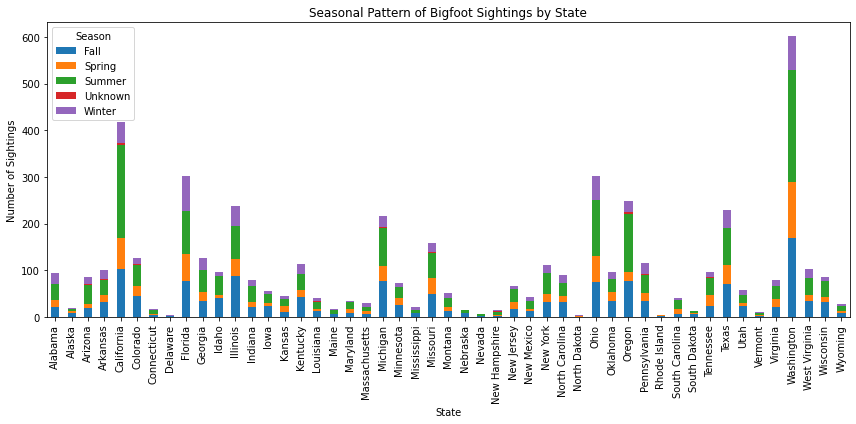

In [17]:
seasonal_counts = df.groupby(['state', 'season']).size().unstack(fill_value=0)

# Plot the seasonal distribution of Bigfoot sightings by state
seasonal_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Seasonal Pattern of Bigfoot Sightings by State')
plt.xlabel('State')
plt.ylabel('Number of Sightings')
plt.xticks(rotation=90)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

Based on the above data, we can conclude that seasons by state doesn't give us any useful information as it does not look like these sightings are concentrated to a partifcular location/region of the USA.

**Question 6**

Can we gain any meaningful insights from the 'observed' descriptions in the dataset? One way to explore this is by creating a word cloud—a visual representation of the most frequently mentioned words in these sightings. By analyzing the common language used in witness reports, we may uncover recurring themes or patterns in the way people describe their experiences. To make the visualization more effective, we’ll remove common stop words (like 'the', 'and', 'it'), allowing the most relevant and descriptive terms to stand out more clearly.

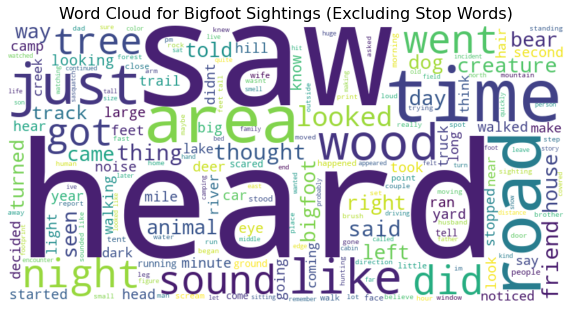

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

# Sample dataframe
# Assuming df is your dataframe with the 'observed' column containing the sightings' description

# Example of how to clean and prepare the 'observed' text data
def preprocess_text(text):
    if isinstance(text, str):  # Ensure the text is a string
        # Convert to lowercase
        text = text.lower()
        # Remove non-alphabetic characters (keep spaces)
        text = re.sub(r'[^a-z\s]', '', text)
        return text
    else:
        return ''  # If it's not a string (e.g., NaN), return an empty string

# Apply preprocessing to the 'observed' column
df['cleaned_observed'] = df['observed'].apply(preprocess_text)

# Create a single string with all the text from the 'observed' column
all_text = ' '.join(df['cleaned_observed'].dropna())

# Create a word cloud while excluding the stop words from the sklearn list
wordcloud = WordCloud(stopwords=ENGLISH_STOP_WORDS, width=800, height=400, background_color='white',random_state=42).generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.title('Word Cloud for Bigfoot Sightings (Excluding Stop Words)', fontsize=16)
plt.show()



While most of the data shows that words such as heard, saw is being called out which further confirms our type of classifications, we can also see additionalal words like wood, road, night revelaing patterns that people that were in the woods, or closer to roads have called out for the bigfoot sightings and also the sighting seems to be more in the night than in the day. Now that we have explored the data a little bit to understand more about the dataset, we can also create machine learning algorithms for predicting type of classification sighting using various methods.

# Machine Learning Algorithms:

Based on the data provided, we will be building a KNN and logstic regression to understand and compare results to see which model will be the best model in helping us to predict the type of classification sightings based on a given set of data. We will have to perform data imputations and also possibly some resampling because our data distribution shows that we have a very low class C in our dataset.

In order to run the models, we have to understand and isolate feature variables that can be used for running ML models. Considering that most of the variables are strings with word descriptions, we will isolate the following columns "**state, season, latitude, longitude, date, classification, temperature_mid**" and run ML model on these features considering the amount of missing values that other string variables have are large and these variables are numeric. We will also  perform data imputation on missing values of these columns and try to impute values based on either season, state, date etc. We will also extend the date variable to inclde month and year as seperate columns to see if months or year has any effect on final prediction

In [19]:
df_testing = df[['state', 'season','latitude','longitude','date','classification','temperature_mid']]
df_testing.head()

,state,season,latitude,longitude,date,classification,temperature_mid
0,Alabama,Summer,NaN,NaN,NaT,Class B,NaN
1,Alaska,Fall,NaN,NaN,NaT,Class A,NaN
2,Rhode Island,Fall,41.45,-71.5,1974-09-20,Class A,73.425
3,Pennsylvania,Summer,NaN,NaN,NaT,Class B,NaN
4,Oregon,Spring,NaN,NaN,NaT,Class B,NaN


In [20]:
df_testing.isna().sum()

state                 0
season                0
latitude            976
longitude           976
date                976
classification        0
temperature_mid    1835
dtype: int64

Based on this we see that latitude and longtidue and date and temperature mid is missing. Based on other variables we will try to impute values for these.

Considering that lat, lon and date has 976 missing values, there could be a chance that it could be the same 976 rows that it is missing. If that is the case, we can verify that and remove all these rows from the dataset as 3 of the 6 feature variable don't have data and hence we will remove them and this would reduce roughly around 20% data in our dataset.

In [21]:
missing_date_lat_lon = df_testing[df_testing['date'].isnull() & df_testing['latitude'].isnull() & df_testing['longitude'].isnull()]
num_rows = len(missing_date_lat_lon)
print(f"Number of rows where date, latitude, and longitude are all missing: {num_rows}")

Number of rows where date, latitude, and longitude are all missing: 976


In [22]:
df_clean = df_testing.dropna(subset=['date', 'latitude', 'longitude'], how='all')

df_clean.isna().sum()

state                0
season               0
latitude             0
longitude            0
date                 0
classification       0
temperature_mid    859
dtype: int64

Now in order to impute the missing data in temperature_mid, we can assign average temperature of the temperature values by months for all the data. We will extract month and year from the date variable and group the temperature mid by month and assign average values for all those missing values.

In [23]:
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

<ipython-input-23-3cf54f58a342>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')


In [24]:
df_clean['month'] = df_clean['date'].dt.month
df_clean['year'] = df_clean['date'].dt.year
print(df_clean[['date', 'month', 'year']].head())

        date  month  year
2 1974-09-20      9  1974
5 1973-09-28      9  1973
6 1971-08-01      8  1971
7 2010-09-01      9  2010
8 1970-09-01      9  1970


<ipython-input-24-414c70d67e6d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['month'] = df_clean['date'].dt.month
<ipython-input-24-414c70d67e6d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = df_clean['date'].dt.year


In [25]:
df_clean.head()

,state,season,latitude,longitude,date,classification,temperature_mid,month,year
2,Rhode Island,Fall,41.45000,-71.50000,1974-09-20,Class A,73.425,9,1974
5,Oklahoma,Fall,35.30110,-99.17020,1973-09-28,Class A,61.425,9,1973
6,Ohio,Summer,39.38745,-81.67339,1971-08-01,Class A,NaN,8,1971
7,New York,Fall,41.29873,-73.73717,2010-09-01,Class A,80.810,9,2010
8,Nevada,Fall,39.59200,-119.97500,1970-09-01,Class B,NaN,9,1970


In [26]:
avg_temp_by_month = df_clean.groupby('month')['temperature_mid'].mean()
avg_temp_by_month

month
1     38.075837
2     38.860455
3     49.613818
4     53.965741
5     61.095991
6     68.827630
7     72.026872
8     70.507845
9     64.949199
10    56.478968
11    46.649053
12    41.183654
Name: temperature_mid, dtype: float64

In [27]:
df_clean['temperature_mid'] = df_clean.groupby('month')['temperature_mid'].transform(lambda x: x.fillna(avg_temp_by_month[x.name]))

<ipython-input-27-e7e786ab6379>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['temperature_mid'] = df_clean.groupby('month')['temperature_mid'].transform(lambda x: x.fillna(avg_temp_by_month[x.name]))


In [28]:
df_clean.isna().sum()

state              0
season             0
latitude           0
longitude          0
date               0
classification     0
temperature_mid    0
month              0
year               0
dtype: int64

In order to perform machine learning, we will have to transform categorical varibles such as season, state into some sort of numeric mapping for the machine to be readable. We will find unique values for state, season, and classification and assign numbers to those. We will use pd.dummies for season and states.


In [29]:
df_clean = pd.get_dummies(df_clean, columns=['season','state'], prefix=['season', 'state'])
df_clean.head()

,latitude,longitude,date,classification,temperature_mid,month,year,season_Fall,season_Spring,season_Summer,season_Winter,state_Alabama,state_Alaska,state_Arizona,state_Arkansas,state_California,state_Colorado,state_Connecticut,state_Delaware,state_Florida,state_Georgia,state_Idaho,state_Illinois,state_Indiana,state_Iowa,state_Kansas,state_Kentucky,state_Louisiana,state_Maine,state_Maryland,state_Massachusetts,state_Michigan,state_Minnesota,state_Mississippi,state_Missouri,state_Montana,state_Nebraska,state_Nevada,state_New Hampshire,state_New Jersey,state_New Mexico,state_New York,state_North Carolina,state_North Dakota,state_Ohio,state_Oklahoma,state_Oregon,state_Pennsylvania,state_Rhode Island,state_South Carolina,state_South Dakota,state_Tennessee,state_Texas,state_Utah,state_Vermont,state_Virginia,state_Washington,state_West Virginia,state_Wisconsin,state_Wyoming
2,41.45000,-71.50000,1974-09-20,Class A,73.425000,9,1974,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,35.30110,-99.17020,1973-09-28,Class A,61.425000,9,1973,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,39.38745,-81.67339,1971-08-01,Class A,70.507845,8,1971,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,41.29873,-73.73717,2010-09-01,Class A,80.810000,9,2010,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,39.59200,-119.97500,1970-09-01,Class B,64.949199,9,1970,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


We will map the classification variables as below to convert categorical target variable into numerical.

In [30]:
classification_mapping = {'Class A': 0, 'Class B': 1, 'Class C': 2}
df_clean['classification_encoded'] = df['classification'].map(classification_mapping)
df_clean.head()

,latitude,longitude,date,classification,temperature_mid,month,year,season_Fall,season_Spring,season_Summer,season_Winter,state_Alabama,state_Alaska,state_Arizona,state_Arkansas,state_California,state_Colorado,state_Connecticut,state_Delaware,state_Florida,state_Georgia,state_Idaho,state_Illinois,state_Indiana,state_Iowa,state_Kansas,state_Kentucky,state_Louisiana,state_Maine,state_Maryland,state_Massachusetts,state_Michigan,state_Minnesota,state_Mississippi,state_Missouri,state_Montana,state_Nebraska,state_Nevada,state_New Hampshire,state_New Jersey,state_New Mexico,state_New York,state_North Carolina,state_North Dakota,state_Ohio,state_Oklahoma,state_Oregon,state_Pennsylvania,state_Rhode Island,state_South Carolina,state_South Dakota,state_Tennessee,state_Texas,state_Utah,state_Vermont,state_Virginia,state_Washington,state_West Virginia,state_Wisconsin,state_Wyoming,classification_encoded
2,41.45000,-71.50000,1974-09-20,Class A,73.425000,9,1974,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
5,35.30110,-99.17020,1973-09-28,Class A,61.425000,9,1973,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,39.38745,-81.67339,1971-08-01,Class A,70.507845,8,1971,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,41.29873,-73.73717,2010-09-01,Class A,80.810000,9,2010,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,39.59200,-119.97500,1970-09-01,Class B,64.949199,9,1970,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


We will assign target variable into y and everything else to be X. We will perform train test splitting of the data as 80% and 20% and run both KNN and logistic regression and compare it's accuracy score to see which model performs better. After that we will also resample the data adding more synthetic data to class C and see if that improves its accuracy score.

In [31]:
df_clean.drop(columns=['classification', 'date'],inplace=True)
X = df_clean.copy()
X.drop(columns=['classification_encoded'],inplace=True)
y = df_clean['classification_encoded']

Now that we have clened the data, we can perform machine learning model on these.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35)  # Adjust test_size as needed

# Create the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors

# Train the model
knn_classifier.fit(X_train, y_train)

# Make predictions
y_pred = knn_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5340
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.55      0.54       410
           1       0.53      0.52      0.53       398
           2       0.00      0.00      0.00         1

    accuracy                           0.53       809
   macro avg       0.36      0.36      0.36       809
weighted avg       0.53      0.53      0.53       809



/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35)

# Feature Scaling (VERY IMPORTANT for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Scale training data
X_test = scaler.transform(X_test)      # Scale test data using the *same* scaler

# Create and train the Logistic Regression model
# Using multinomial logistic regression for multi-class classification
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000) # Increased max_iter
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5946
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.60      0.60       410
           1       0.59      0.60      0.59       398
           2       0.00      0.00      0.00         1

    accuracy                           0.59       809
   macro avg       0.40      0.40      0.40       809
weighted avg       0.59      0.59      0.59       809



/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Based on runing the ML model we can see that model accuracy is 53% for KNN and 59% for logistic regression, our model performs slightly better than a random guess at this point. So, let's see further if oversampling Class C could lead to better results.'

**Since Class C distrubtion was very low, let's perform some oversampling of those data to try and address the class imbalance problem. We will add counts similar to Class A & B**

In [34]:
from sklearn.utils import resample
minor = df_clean[df_clean['classification_encoded'] == 2]
major = df_clean[(df_clean['classification_encoded'] == 0) | (df_clean['classification_encoded'] == 1)]
resampled_data = resample(minor, n_samples=int(len(major) / 2), replace=True, random_state=42)
df_concat_row = pd.concat([resampled_data, major])

In [35]:
X_resample = df_concat_row.drop(columns=['classification_encoded'])
y_resample = df_concat_row['classification_encoded']
X_train, X_test, y_train, y_test = train_test_split(X_resample, y_resample, test_size=0.2, random_state=35)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)     

# Create and train the Logistic Regression model
# Using multinomial logistic regression for multi-class classification
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6675
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.47      0.53       415
           1       0.55      0.60      0.57       382
           2       0.81      0.94      0.87       412

    accuracy                           0.67      1209
   macro avg       0.66      0.67      0.66      1209
weighted avg       0.66      0.67      0.66      1209



In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_resample, y_resample, test_size=0.2, random_state=35)  # Adjust test_size as needed

# Create the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors

# Train the model
knn_classifier.fit(X_train, y_train)

# Make predictions
y_pred = knn_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6973
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       415
           1       0.53      0.54      0.54       382
           2       0.98      1.00      0.99       412

    accuracy                           0.70      1209
   macro avg       0.69      0.69      0.69      1209
weighted avg       0.70      0.70      0.70      1209



# We can conclude that oversampling of data yeilds better accuracy results than the original dataset. KNN with oversampling of Class C yields an accuracy of 69% while logistic regression with oversampling yeilds an accuracy of 66%. 